In [1]:
using Pkg
Pkg.activate(".")
# Pkg.instantiate()
Pkg.status()

  Activating project at `c:\Users\MGAJ\OneDrive - Danmarks Tekniske Universitet\DTU\Kandidat\5_Semester\Speciale\discovering_hidden_physics\scripts`


Status `C:\Users\MGAJ\OneDrive - Danmarks Tekniske Universitet\DTU\Kandidat\5_Semester\Speciale\discovering_hidden_physics\scripts\Project.toml`
⌃ [b0b7db55] ComponentArrays v0.15.28
  [a93c6f00] DataFrames v1.7.0
  [0c46a032] DifferentialEquations v7.16.1
  [31c24e10] Distributions v0.25.120
  [f67ccb44] HDF5 v0.17.2
  [0e44f5e4] Hwloc v3.3.0
⌃ [b2108857] Lux v1.13.5
⌅ [961ee093] ModelingToolkit v9.80.1
  [429524aa] Optim v1.13.2
⌃ [7f7a1694] Optimization v4.3.0
  [36348300] OptimizationOptimJL v0.4.3
  [500b13db] OptimizationPolyalgorithms v0.3.0
  [48d54b35] PEtab v3.8.4 `https://github.com/sebapersson/PEtab.jl.git#PEtabUDEProblem`
⌃ [91a5bcdd] Plots v1.40.14
⌃ [295af30f] Revise v3.8.0
⌃ [1ed8b502] SciMLSensitivity v7.87.0
  [c3572dad] Sundials v4.28.0
⌃ [0c5d862f] Symbolics v6.45.0
  [fe2206b3] TidierData v0.17.0
Info Packages marked with ⌃ and ⌅ have new versions available. Those with ⌃ may be upgradable, but those with ⌅ are restricted by compatibility constraints from upgrading.

In [2]:
using Revise, Optimization, ModelingToolkit,DifferentialEquations,Plots, Lux, PEtab, Random, Distributions
seed = 0 #set seed for reproducibility
rng = Random.default_rng() #create a random number generator with the seed

TaskLocalRNG()

## GENERATE DATA

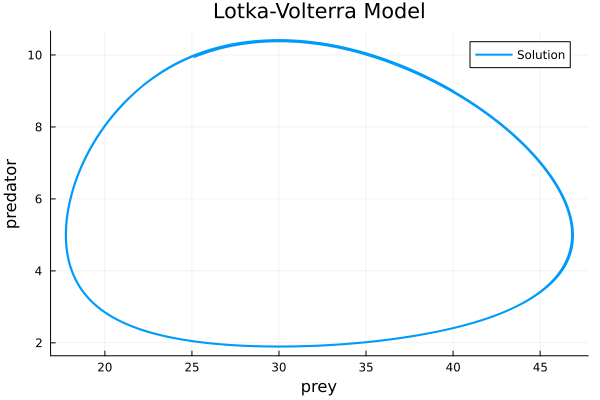

In [145]:
## Lotka-Volterra equations
@parameters α β γ δ
@independent_variables  t
vars = @variables x(t) y(t) z(t)
Dt = Differential(t)
eqs = [
    Dt(x) ~ α * x - β * x * y,
    Dt(y) ~ δ * x * y - γ * y,
]
measured_quantities = [z ~ x + y]  # Example of a measured quantity
@named sys = ODESystem(eqs, t, [x, y], [α, β, γ, δ]; observed = measured_quantities)
sys = complete(sys)
params =  Dict([α => 0.1, 
                β => 0.02, 
                δ => 0.01,
                γ => 0.3])

u0 = Dict([x => 40.0, y => 9.0])
tspan = (0.0, 80.0)
dt = 0.1

sys = complete(sys)
odefun = ODEFunction(sys, unknowns(sys), parameters(sys))
prob = ODEProblem(odefun, [40.0, 9.0], tspan, [0.1, 0.02, 0.01, 0.3])
sol = solve(prob, Tsit5(), saveat=dt)
data = hcat(sol.u...)'
timedata = sol.t
plot(sol, vars=(x, y), xlabel="prey", ylabel="predator",
     title="Lotka-Volterra Model", label="Solution",
     legend=:topright, linewidth=2, markersize=4)


In [146]:
#save model directory
rootdir = dirname(@__DIR__)
model_dir = joinpath(rootdir , "models", "lotka_volterra", "SINDy", "seed_$seed")
#boolean to indicate whether to load models or train models
load_models = true 
model_dir

"c:\\Users\\MGAJ\\OneDrive - Danmarks Tekniske Universitet\\DTU\\Kandidat\\5_Semester\\Speciale\\discovering_hidden_physics\\models\\lotka_volterra\\SINDy\\seed_0"

# Hidden dynamics with SINDy

Assuming only partial knowledge of the Lotka-Volterra equations, we can use SINDy to discover the hidden dynamics.
It's assumed the known dynamics are the ones known whenever a species is present in a vacuum, i.e. when the other species is not present. It's desired to discover the interaction terms between the species, which are not known.
### Known dynamics
These are the dynamics of the species when the other species is not present, i.e. when the other species is in a vacuum.
$$
\begin{align*}
\dot{x} &= \alpha x \\
\dot{y} &= - \gamma y \\
\end{align*}
$$
### Unknown dynamics
# The interaction terms between the species, which are not known.
$$
\begin{align*}
\dot{x} &= - \beta xy \\
\dot{y} &= \delta xy
\end{align*}
$$


In [147]:
known_eqs = [
    Dt(x) ~ α * x
    Dt(y) ~ -γ * y
]
unknown_gt_eqs = [
    Dt(x) ~ -β * x * y,
    Dt(y) ~ δ * x * y,
]
deviance = 0.1 # deviance for the unknown_gt equations
params_guess_known = Dict([α => 0.1, # + deviance * randn()
                        γ => 0.3, # + deviance * randn()])
                        ])

params_guess_unknown_gt = Dict([β => 0.02,# + deviance * randn()
                        δ => 0.01 # + deviance * randn()])
                        ])


@named sys_known = ODESystem(known_eqs, t, [x, y], [α, γ], defaults = params_guess_known, observed = measured_quantities)
@named sys_unknown_gt = ODESystem(unknown_gt_eqs, t, [x, y], [β, δ], defaults = params_guess_unknown_gt)
sys_known = complete(sys_known)
sys_unknown_gt = complete(sys_unknown_gt)

Model sys_unknown_gt:
Equations (2):
  2 standard: see equations(sys_unknown_gt)
Unknowns (2): see unknowns(sys_unknown_gt)
  x(t)
  y(t)
Parameters (2): see parameters(sys_unknown_gt)
  β [defaults to 0.02]
  δ [defaults to 0.01]

# Data for fitting SINDy


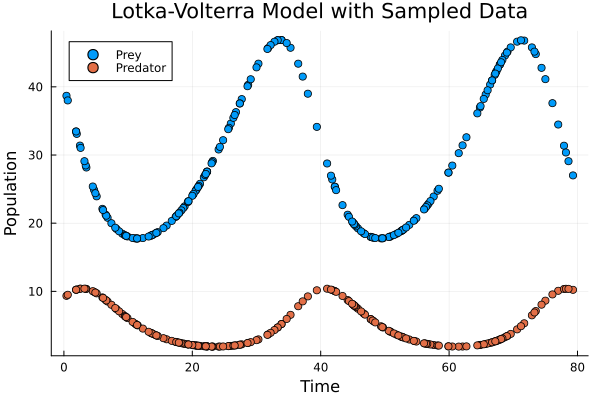

In [148]:
using DataFrames
n_data = size(data, 1)
sample_size = 200

sample_idcs = rand(1:n_data, sample_size)
scatter(timedata[sample_idcs], data[sample_idcs, :], label=["Prey" "Predator"], xlabel="Time", ylabel="Population", title="Lotka-Volterra Model with Sampled Data")

In [149]:
#split train and test data at 80% of the time series
train_fraction = 0.8
test_time = timedata[1:round(Int, n_data * train_fraction)]

prey_df = DataFrame(simulation_id = "cond1", obs_id = "prey_o", time = timedata[sample_idcs], measurement= data[sample_idcs, 1],)
predator_df = DataFrame(simulation_id = "cond1", obs_id = "predator_o", time = timedata[sample_idcs], measurement= data[sample_idcs, 2],)
measurements = vcat(prey_df, predator_df)

#split dataframe into train and test sets
train_idcs = findall(measurements.time .<= test_time[end])
test_idcs = findall(measurements.time .> test_time[end])
#save train and test data½
train_measurements = measurements[train_idcs, :]
test_measurements = measurements[test_idcs, :]

Row,simulation_id,obs_id,time,measurement
,String,String,Float64,Float64
1,cond1,prey_o,75.0,41.1273
2,cond1,prey_o,67.3,42.1369
3,cond1,prey_o,65.7,38.863
4,cond1,prey_o,79.3,27.0076
5,cond1,prey_o,77.0,34.4712
6,cond1,prey_o,77.9,31.3643
7,cond1,prey_o,71.7,46.7827
8,cond1,prey_o,66.7,40.9459
9,cond1,prey_o,78.2,30.3702


### Proposed basis for SINDy library

In [150]:
function polynomial_basis(x::Array, degree::Int = 1)
    @assert degree > 0
    n_x = length(x)
    n_c = binomial(n_x + degree, degree)
    eqs = Array{Num}(undef, n_c)
    _check_degree(x) = sum(x) <= degree ? true : false
    itr = Base.Iterators.product([0:degree for i in 1:n_x]...)
    itr_ = Base.Iterators.Stateful(Base.Iterators.filter(_check_degree, itr))
    filled = false
    @inbounds for i in 1:n_c
        eqs[i] = 1
        filled = true
        for (xi, ci) in zip(x, popfirst!(itr_))
            if !iszero(ci)
                filled ? eqs[i] = xi^ci : eqs[i] *= xi^ci
                filled = false
            end
        end
    end
    eqs
end

species = unknowns(sys_known)
unknown_basis = polynomial_basis(species, 2) 

6-element Vector{Num}:
         1
      x(t)
    x(t)^2
      y(t)
 x(t)*y(t)
    y(t)^2

In [151]:
using Symbolics, Base

In [152]:
Base.occursin(needle::Num, haystack::Int64) = false # Override occursin for Num types to always return false whenever haystack is an Int64
function create_unknown_eqs(sys_known::AbstractTimeDependentSystem, unknown_basis::Vector{T}; Ξ = nothing) where T <: Union{Num}
    #remove basis functions that are already in the known system
    if isnothing(Ξ)
        @parameters Ξ[1:length(unknown_basis), 1:length(unknowns(sys_known))]
    end 
    known_species = unknowns(sys_known)
    known_eqs = equations(sys_known)
    Ξ = hcat(Ξ)
    #create empty vector to hold the unknown equations
    unknown_eqs = Vector{Any}(undef, length(known_eqs))
    #if equation is already in the known system, remove it from the unknown basis
    for (i,k_eq) in enumerate(known_eqs)
        eq_basis_funs = copy(unknown_basis)
        for (j, basis_fun) in enumerate(unknown_basis)
            if occursin(basis_fun, k_eq.rhs)
                eq_basis_funs[j] = 0
            end
        end
        unknown_eqs[i] = Equation(k_eq.lhs, sum(eq_basis_funs .* Ξ[i, :]))
    end 
    return unknown_eqs
end

create_unknown_eqs (generic function with 1 method)

In [153]:
params

Dict{Num, Float64} with 4 entries:
  α => 0.1
  β => 0.02
  δ => 0.01
  γ => 0.3

In [154]:
@parameters Ξ[1:length(known_eqs), 1:length(unknown_basis)]
default_params = Dict([Ξ[i, j] => 0.0 for i in 1:length(known_eqs), j in 1:length(unknown_basis)])
default_params[Ξ[1,5]] = - params[β]
default_params[Ξ[2,5]] = params[δ] # Set the default parameters for the unknown equations

uk_eqs = create_unknown_eqs(sys_known, unknown_basis; Ξ = Ξ)
@named sys_SINDy = ODESystem(uk_eqs, t)#, defaults = default_params)
sys_SINDy = complete(sys_SINDy)

Model sys_SINDy:
Equations (2):
  2 standard: see equations(sys_SINDy)
Unknowns (2): see unknowns(sys_SINDy)
  x(t)
  y(t)
Parameters (10): see parameters(sys_SINDy)
  Ξ[1, 3]
  Ξ[2, 5]
  Ξ[1, 5]
  Ξ[1, 6]
  ⋮

┌ Warning: At t=0.03485894340709504, dt was forced below floating point epsilon 6.938893903907228e-18, and step error estimate = 8.390237549489685. Aborting. There is either an error in your model specification or the true solution is unstable (or the true solution can not be represented in the precision of Float64).
└ @ SciMLBase C:\Users\MGAJ\.julia\packages\SciMLBase\sN1tQ\src\integrator_interface.jl:623


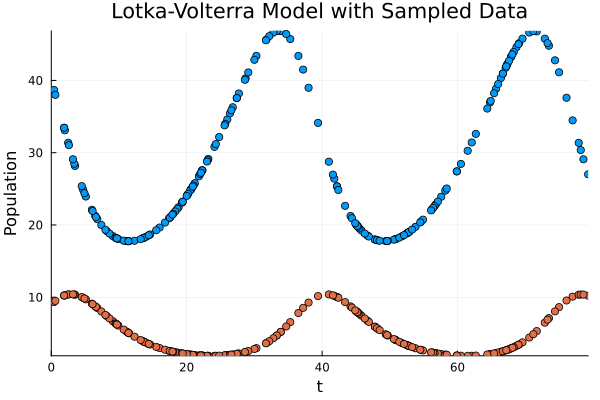

In [196]:
include("../src/hybrid_model.jl")
# hmodel = HybridModel(sys_known, sys_unknown_gt; rng = rng)
hmodel = HybridModel(sys_known, sys_SINDy; rng = rng)

initp = init_params(hmodel)
### ENSEMBLE DATA ###

# initial_conditions  = [
#     [40.0, 9.00],
#     [20.0, 8.0],
#     [10, 7.0], 
# ]

# initial_conditions  = [
#     Dict([x => 40.0, y => 9.0]),
#     Dict([x => 20.0, y => 8.0]),
#     Dict([x => 10.0, y => 7.0]),
# ]

initial_conditions = Dict(
    "cond1" => Dict([x => 40.0, y => 9.0]), #remember to define variables before using them
)

ens_prob = EnsembleProblem(hmodel, initial_conditions, tspan, initp)
sol = solve(ens_prob, Rodas5(), EnsembleDistributed(), trajectories = length(initial_conditions), saveat = dt)
scatter(timedata[sample_idcs], data[sample_idcs, :], label=["Prey" "Predator"], xlabel="Time", ylabel="Population", title="Lotka-Volterra Model with Sampled Data")
plot!(sol)

## Model Fitting

In [157]:
using Optimization
using Optim
using OptimizationOptimJL
using OptimizationPolyalgorithms

In [172]:
lasso_penalty = 1e-3
obs = Dict("prey_o" => x, "predator_o" => y)
u0map = Dict([x => 40.0, y => 9.0])
peprob = HybridPEProblem(hmodel, obs, train_measurements, u0map; 
                   conditions = initial_conditions, include_plot = false,
                   ens_alg = EnsembleSerial(),
                   alg = Rosenbrock23(),
                     lasso_penalty = lasso_penalty,
                   );

In [242]:
adalg = Optimization.AutoForwardDiff() #Optimization.AutoZygote() # Optimization.AutoReverseDiff(compile=false) # 
optfun = OptimizationFunction((p, p_useless) -> peprob.obj_func(p), adalg)
p_guess = abs.(1e-4* randn(length(initp)).*init_params(hmodel))
println(p_guess)
optfun(p_guess, nothing) #test the objective function

(sys = (α = 9.474695497693746e-6, γ = 4.400607373001028e-5), surrogate = (Ξ[1, 3] = 0.0001826048347843866, Ξ[2, 5] = 5.9871319774921294e-5, Ξ[1, 5] = 0.00010536729827171386, Ξ[1, 6] = 7.785988897915543e-6, Ξ[2, 3] = 3.315674276781507e-5, Ξ[1, 1] = 0.00013080044229786208, Ξ[2, 1] = 3.5598492163358245e-5, Ξ[2, 6] = 1.5282709590049392e-5, Ξ[1, 4] = 0.00015815462500886696, Ξ[2, 2] = 3.631702321661967e-5))


195879.65393442794

In [243]:
optprob = OptimizationProblem(optfun, p_guess, lb = zeros(length(initp)), ub = ones(length(initp)) .* 1e1)

OptimizationProblem. In-place: true
u0: ComponentVector{Float64}(sys = (α = 9.474695497693746e-6, γ = 4.400607373001028e-5), surrogate = (Ξ[1, 3] = 0.0001826048347843866, Ξ[2, 5] = 5.9871319774921294e-5, Ξ[1, 5] = 0.00010536729827171386, Ξ[1, 6] = 7.785988897915543e-6, Ξ[2, 3] = 3.315674276781507e-5, Ξ[1, 1] = 0.00013080044229786208, Ξ[2, 1] = 3.5598492163358245e-5, Ξ[2, 6] = 1.5282709590049392e-5, Ξ[1, 4] = 0.00015815462500886696, Ξ[2, 2] = 3.631702321661967e-5))

In [244]:
sol = solve(optprob, Optim.LBFGS(); maxiters = 100,
            show_trace = true, show_every = 5)

Fminbox
-------
Initial mu = 6.07866

Fminbox iteration 1
-------------------
Calling inner optimizer with mu = 6.07866

(numbers below include barrier contribution)
Iter     Function value   Gradient norm 
     0     1.964437e+05     1.648524e+09
 * Current step size: 1.0
 * time: 0.0
 * g(x): (sys = (α = 3.264752365893868e7, γ = -2.112497221126565e6), surrogate = (Ξ[1, 3] = 1.6485238101302803e9, Ξ[2, 5] = 1.060455782766129e8, Ξ[1, 5] = 3.730226182859541e8, Ξ[1, 6] = 8.440769968714161e7, Ξ[2, 3] = 4.687204366963279e8, Ξ[1, 1] = 664304.2574978218, Ξ[2, 1] = 191800.72120216952, Ξ[2, 6] = 2.3992892135604843e7, Ξ[1, 4] = 7.383625582202179e6, Ξ[2, 2] = 9.345593139366487e6))
 * x: (sys = (α = 9.474695497693746e-6, γ = 4.400607373001028e-5), surrogate = (Ξ[1, 3] = 0.0001826048347843866, Ξ[2, 5] = 5.9871319774921294e-5, Ξ[1, 5] = 0.00010536729827171386, Ξ[1, 6] = 7.785988897915543e-6, Ξ[2, 3] = 3.315674276781507e-5, Ξ[1, 1] = 0.00013080044229786208, Ξ[2, 1] = 3.5598492163358245e-5, Ξ[2, 6] = 

┌ Warning: At t=8.222528558869525, dt was forced below floating point epsilon 1.7763568394002505e-15, and step error estimate = 16.36930985186291. Aborting. There is either an error in your model specification or the true solution is unstable (or the true solution can not be represented in the precision of ForwardDiff.Dual{ForwardDiff.Tag{var"#1623#1624", Float64}, Float64, 12}).
└ @ SciMLBase C:\Users\MGAJ\.julia\packages\SciMLBase\sN1tQ\src\integrator_interface.jl:623


BoundsError: BoundsError: attempt to access 44-element Vector{ForwardDiff.Dual{ForwardDiff.Tag{var"#1623#1624", Float64}, Float64, 12}} at index [71]

In [249]:

function prob_func(prob, i, repeat)
    remake(prob, u0 = abs.(1e-2* randn(length(initp)).*p_guess)) 
end

prob_func (generic function with 1 method)

In [250]:
opt_n = 30 #number of optimization runs
ensembleprob = Optimization.EnsembleProblem(optprob; prob_func)
optsol = Optimization.solve(ensembleprob, Optim.LBFGS(),
    EnsembleThreads(), trajectories = opt_n, maxiters = 100)

┌ Warning: At t=1.4018770427534981, dt was forced below floating point epsilon 2.220446049250313e-16, and step error estimate = 607.666758954056. Aborting. There is either an error in your model specification or the true solution is unstable (or the true solution can not be represented in the precision of ForwardDiff.Dual{ForwardDiff.Tag{var"#1623#1624", Float64}, Float64, 12}).
└ @ SciMLBase C:\Users\MGAJ\.julia\packages\SciMLBase\sN1tQ\src\integrator_interface.jl:623


BoundsError: BoundsError: attempt to access 4-element Vector{ForwardDiff.Dual{ForwardDiff.Tag{var"#1623#1624", Float64}, Float64, 12}} at index [71]

In [228]:
@show findmin(i -> optsol[i].objective, 1:opt_n)[1]

(findmin((i->(#= c:\Users\MGAJ\OneDrive - Danmarks Tekniske Universitet\DTU\Kandidat\5_Semester\Speciale\discovering_hidden_physics\scripts\jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X54sZmlsZQ==.jl:1 =#
            (optsol[i]).objective)), 1:opt_n))[1] = 48096.22969873509


48096.22969873509

In [230]:
[opt.objective for opt in optsol]

30-element Vector{Float64}:
 48550.52998706084
 48450.01986101756
 49501.491973489785
 48683.69355427901
 48704.47102956335
 48149.1153004437
 48708.34797550252
 48834.08438190311
 48136.72531086156
 48807.22908797982
     ⋮
 49262.43473313741
 48603.2748979579
 49225.15227298182
 48133.51662750103
 48861.48712419056
 49253.674402062294
 48391.212804768045
 48499.74093658846
 48212.88001613508

In [19]:
# #### PETAB Model
# using PEtab
# #Setup observables
# @parameters σ
# obs_x = PEtabObservable(x, σ)
# obs_y = PEtabObservable(y, σ)
# obs = Dict("prey_o" => obs_x, "predator_o" => obs_y)


# #setup initial conditions
# cond1 = Dict(:x => 40.0, :y => 9.0)
# conds = Dict("cond1" => cond1)
# # Setup parameters

# #model parameters

# estimate = true # Set to true if you want to estimate the parameters
# p_α = PEtabParameter(α, lb = 1e-6, ub = 1e0, estimate = estimate, scale = :lin, value = 0.1)
# p_β = PEtabParameter(β, lb = 1e-6, ub = 1e0, estimate = estimate, scale = :lin, value = 0.02)
# p_γ = PEtabParameter(γ, lb = 1e-6, ub = 1e0, estimate = estimate, scale = :lin, value = 0.3)
# p_δ = PEtabParameter(δ, lb = 1e-6, ub = 1e0, estimate = estimate, scale = :lin, value = 0.01)
# #noise parameter
# p_σ = PEtabParameter(σ, lb = 1e-6, ub = 1e0, estimate = true, scale = :lin, value = 0.2)
# pest = [
#     p_α,p_γ, p_σ
# ]

# #parameters for the unknown system
# pest = [pest..., p_β, p_δ]

# # for ξ in parameters(sys_SINDy)
# #     p_ξ = PEtabParameter(Symbol(string(ξ)), lb = 1e-6, ub = 1e0, estimate = estimate, scale = :lin, value = 0.1)
# #     push!(pest, p_ξ)
# # end

# odesolver = PEtab.ODESolver(Tsit5(); abstol = 1e-6, reltol = 1e-6)

# train_model = PEtabModel(hodeprob,obs, train_measurements, pest; simulation_conditions  = conds, verbose = true)
# test_model = PEtabModel(hodeprob,obs, test_measurements, pest; simulation_conditions  = conds, verbose = true)
# petab_prob = PEtabODEProblem(train_model; odesolver = odesolver)                             
# petab_prob_test = PEtabODEProblem(test_model)

In [20]:
# p = get_x(petab_prob)
# #plot simulated data
# scatter(train_measurements.time, petab_prob.simulated_values(p))

In [22]:
# using Optim
# n_runs = 20 # Number of runs for multistart optimization
# # load_models = false
# # if load_models
# #     # Load the models from the model directory
# #     res = PEtabMultistartResult(model_dir; which_run = 1)
# # else
# #     # Run the multistart optimization
# #     nprocs = 1 # Set the number of processes for parallel optimization
# #     res = calibrate_multistart(petab_prob, IPNewton(), n_runs, options = Optim.Options(show_trace = true, iterations = 1000, show_every = 10), nprocs = nprocs; seed = seed, save_trace = true, dirsave = model_dir)
# # end

In [23]:
# using Optimization
# using OptimizationOptimJL

# opt_prob = OptimizationProblem(petab_prob,box_constraints = false)

In [24]:
# import Markdown
# Base.showable(::MIME"text/markdown", ::Markdown.MD) = false

In [25]:
# (ComponentVector(;σ = 0.1), initp)

In [26]:
# x0 = get_x(petab_prob)

In [27]:
# x0 = get_x(petab_prob)
# opt_prob.u0 .= x0
# res = solve(opt_prob, Optim.Adam())